In [1]:
import pandas as pd #Importar o pandas para lidar com os datasets
import numpy as np #Importar o numpy para lidar com arrays
import seaborn as sns #Importar o Seaborn para criar o Grafico

In [2]:
data_file = pd.read_csv('dataset.csv') #Importando o dataset

In [3]:
data_file #Dataset

,id,temperatura,humidade_relativa,luz,CO2,humidade_absoluta,ocupado
0,1,21.378188,25.525852,134.009125,586.057521,0.003686,0.0
1,2,19.827806,27.059169,132.640046,393.046090,0.003989,0.0
2,3,23.425627,31.104946,436.200084,1349.229342,0.005386,1.0
3,4,20.166031,31.384292,0.000000,477.423360,0.004294,0.0
4,5,21.156009,23.636922,192.408834,579.184588,0.003741,0.0
...,...,...,...,...,...,...,...
13995,13996,20.790316,32.109903,0.000000,569.385930,0.005087,0.0
13996,13997,21.398158,20.065245,0.000000,550.507665,0.002751,0.0
13997,13998,18.577101,30.580843,116.840215,462.893632,0.004181,0.0
13998,13999,20.927935,21.641251,0.000000,439.780668,0.003457,0.0


In [4]:
data_file.dropna(inplace=True)#Eliminar linhas duplicadas
data_file.drop_duplicates(keep='first',inplace=True)#Eliminar Linhas duplicadas mantendo sempre a primeira
data_file.count()

id                   13993
temperatura          13993
humidade_relativa    13993
luz                  13993
CO2                  13993
humidade_absoluta    13993
ocupado              13993
dtype: int64

In [5]:
print(data_file.corr().ocupado.abs().sort_values())#Ver a relação que as variaveis preditivas tem com a variavel alvo

id                   0.000311
humidade_relativa    0.056890
humidade_absoluta    0.262842
luz                  0.404335
CO2                  0.502164
temperatura          0.511779
ocupado              1.000000
Name: ocupado, dtype: float64


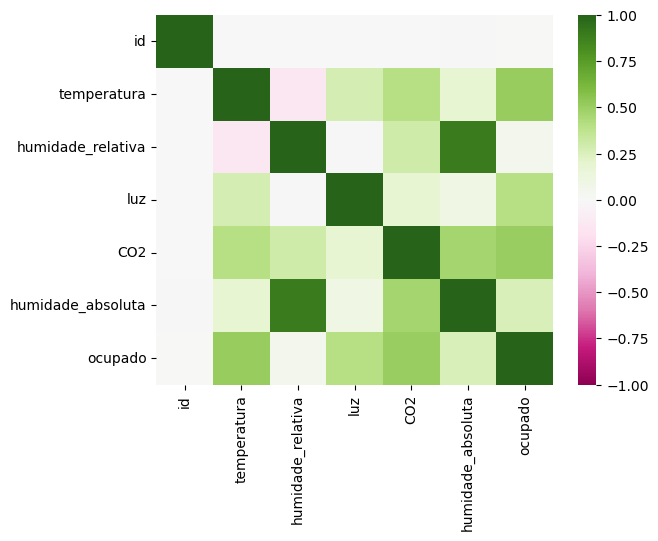

In [6]:
g = sns.heatmap(data_file.corr(), vmin=-1, vmax=1,cmap="PiYG") #Grafico Heatmap

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
#Particionando a Tabela
Xtreino,Xrest,ytreino,yrest =train_test_split(data_file.drop("ocupado",axis=1),data_file[["ocupado"]],test_size=0.50, random_state=1,stratify=data_file.ocupado)
print(Xtreino.shape,Xrest.shape,ytreino.shape,yrest.shape)

(6996, 6) (6997, 6) (6996, 1) (6997, 1)


In [9]:
ytreino.value_counts()#Ver o numero de ocupados e não ocupados da variavel Ytreino

ocupado
0.0        5378
1.0        1618
Name: count, dtype: int64

# K vizinhos proximos

In [10]:
Xvalid,Xteste,yvalid,yteste =train_test_split(Xrest,yrest,test_size=0.50, random_state=1,stratify=yrest)

In [11]:
from sklearn.neighbors import KNeighborsClassifier #Modelo K vizinhos Proximos

In [12]:
for k in range(1,20):
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X=Xtreino, y=ytreino)
    acuracia=modelo.score(X=Xvalid, y=yvalid)
    print("Tx de acerto considerando k={} vizinhos: {:.1f}%".format(k,acuracia*100))

C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expe

Tx de acerto considerando k=1 vizinhos: 85.9%
Tx de acerto considerando k=2 vizinhos: 86.4%
Tx de acerto considerando k=3 vizinhos: 88.1%
Tx de acerto considerando k=4 vizinhos: 88.0%
Tx de acerto considerando k=5 vizinhos: 89.1%
Tx de acerto considerando k=6 vizinhos: 88.7%
Tx de acerto considerando k=7 vizinhos: 89.1%


C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expe

Tx de acerto considerando k=8 vizinhos: 88.9%
Tx de acerto considerando k=9 vizinhos: 89.2%
Tx de acerto considerando k=10 vizinhos: 88.6%
Tx de acerto considerando k=11 vizinhos: 89.0%
Tx de acerto considerando k=12 vizinhos: 88.6%


C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expe

Tx de acerto considerando k=13 vizinhos: 88.9%
Tx de acerto considerando k=14 vizinhos: 88.8%
Tx de acerto considerando k=15 vizinhos: 88.9%
Tx de acerto considerando k=16 vizinhos: 88.9%
Tx de acerto considerando k=17 vizinhos: 89.2%
Tx de acerto considerando k=18 vizinhos: 88.9%
Tx de acerto considerando k=19 vizinhos: 89.0%


C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [13]:
K=9
modelok = KNeighborsClassifier(n_neighbors=K)
modelok.fit(X=Xtreino, y=ytreino)
acuracia=modelok.score(X=Xteste, y=yteste)
print("Tx de acerto do melhor modelo (k={}), no conjunto de teste: {:.1f}%".format(K,acuracia*100))

Tx de acerto do melhor modelo (k=9), no conjunto de teste: 89.3%


C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [14]:
from sklearn.model_selection import GridSearchCV

In [15]:
parameters_KNN = {
    'n_neighbors': range(1,25),
    'algorithm':['auto','ball_tree','kd_tree','brute'],
    'leaf_size': (30,20,40,1),
    'p': (1,2),
    'weights': ('uniform', 'distance'),
    'metric': ('minkowski', 'chebyshev'),}

In [16]:
grid_search_KNN = GridSearchCV(
    estimator=modelok,
    param_grid=parameters_KNN,
    scoring = 'accuracy',
    n_jobs = -1,
    cv = 5
)
grid_search_KNN.fit(X=Xtreino, y=ytreino)

C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,estimator,KNeighborsCla...n_neighbors=9)
,param_grid,"{'algorithm': ['auto', 'ball_tree', ...], 'leaf_size': (30, ...), 'metric': ('minkowski', ...), 'n_neighbors': range(1, 25), ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,21


In [17]:
grid_search_KNN.best_params_

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'n_neighbors': 21,
 'p': 1,
 'weights': 'distance'}

In [18]:
grid_search_KNN.score(X=Xteste, y=yteste)

0.901686196056016

# Regressão Logistica

In [19]:
treino, teste = train_test_split(data_file,test_size=0.25, random_state=30, stratify=data_file.ocupado)

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
modelo_Regessão=LogisticRegression()

In [22]:
modelo_Regessão.fit(X=treino.drop("ocupado", axis=1), y=treino.ocupado)#Criar o modelo com 2 variaveis de treino

C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
R2=modelo_Regessão.score(teste.drop("ocupado", axis=1),teste.ocupado)#obter o Score para os dados de teste com duas variaveis
print(round(R2,2))

0.9


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
grid={"C":np.logspace(-3,3,7,8,9), "penalty":["l1","l2","13","14","15","16","17"]}# l1 lasso l2 ridge
logreg=modelo_Regessão
logreg_cv=GridSearchCV(logreg,grid,cv=10)
logreg_cv.fit(treino.drop("ocupado", axis=1),treino.ocupado)

C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

,estimator,LogisticRegression()
,param_grid,"{'C': array([1.3717...29000000e+02]), 'penalty': ['l1', 'l2', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:610: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 593, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1306, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 439, in _check_solver
    raise ValueError("Logistic Regression supports only penalties in %s,"
ValueError: Logistic Regression supports only penalties in ['l1', 'l2', 'elasticnet', 'none'], got 15.

  warnings.warn("Estimator fit failed. The score on this train-test"
C:\Users\Cassi\anaconda3\lib\site-packages\skle

C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:610: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 593, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1306, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 439, in _check_solver
    raise ValueError("Logistic Regression supports only penalties in %s,"
ValueError: Logistic Regression supports only penalties in ['l1', 'l2', 'elasticnet', 'none'], got 16.

  warnings.warn("Estimator fit failed. The score on this train-test"
C:\Users\Cassi\anaconda3\lib\site-packages\skle

C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:610: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 593, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1306, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 443, in _check_solver
    raise ValueError("Solver %s supports only 'l2' or 'none' penalties, "
ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

  warnings.warn("Estimator fit failed. The score on this train-test"
C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_v

...

C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:610: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 593, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1306, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 439, in _check_solver
    raise ValueError("Logistic Regression supports only penalties in %s,"
ValueError: Logistic Regression supports only penalties in ['l1', 'l2', 'elasticnet', 'none'], got 14.

  warnings.warn("Estimator fit failed. The score on this train-test"
C:\Users\Cassi\anaconda3\lib\site-packages\skle

C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:610: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 593, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1306, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 439, in _check_solver
    raise ValueError("Logistic Regression supports only penalties in %s,"
ValueError: Logistic Regression supports only penalties in ['l1', 'l2', 'elasticnet', 'none'], got 16.

  warnings.warn("Estimator fit failed. The score on this train-test"
C:\Users\Cassi\anaconda3\lib\site-packages\skle

C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:610: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 593, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1306, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\Cassi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 439, in _check_solver
    raise ValueError("Logistic Regression supports only penalties in %s,"
ValueError: Logistic Regression supports only penalties in ['l1', 'l2', 'elasticnet', 'none'], got 17.

  warnings.warn("Estimator fit failed. The score on this train-test"
C:\Users\Cassi\anaconda3\lib\site-packages\skle

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': array([1.37174211e-03, 1.23456790e-02, 1.11111111e-01, 1.00000000e+00,
       9.00000000e+00, 8.10000000e+01, 7.29000000e+02]),
                         'penalty': ['l1', 'l2', '13', '14', '15', '16', '17']})

In [26]:
logreg_cv.best_params_

{'C': np.float64(1.0), 'penalty': 'l2'}

In [27]:
logreg_cv.score(X=teste.drop("ocupado", axis=1), y=teste.ocupado)

0.8968276650471563

# Arvore de decisão(Modelo com melhor score)

In [28]:
from sklearn.tree import DecisionTreeClassifier #Modelo Arvores de Decisão
modelo_DecisionTree = DecisionTreeClassifier()

In [29]:
Xtreino,Xteste,ytreino,yteste =train_test_split(data_file.drop("ocupado",axis=1),data_file[["ocupado"]],test_size=0.25, random_state=1,stratify=data_file.ocupado)

In [30]:
ytreino.value_counts()#Ver o numero de ocupados e não ocupados da variavel Ytreino

ocupado
0.0        8066
1.0        2428
Name: count, dtype: int64

In [31]:
modelo_DecisionTree.fit(Xtreino,ytreino)#Treinando o modelo

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
modelo_DecisionTree.score(X=Xteste, y=yteste)#score do modelo treinado

0.9122606458988283

In [33]:
from sklearn.model_selection import GridSearchCV#Importando o GridSearchCV

In [34]:
#Criando a Grelha de valores para o GridSearchCV
grelha_valores={'criterion':['gini','entropy'],'max_depth':[2,3,4,5,10,20,30],"min_samples_split":range(1,20),"min_samples_leaf":range(1,15)}

In [35]:
modelo__DecisionTree = DecisionTreeClassifier()
procura_modelo = GridSearchCV(modelo_DecisionTree,param_grid=grelha_valores,cv=5,verbose=1,n_jobs=-1)
procura_modelo.fit(X=Xtreino, y=ytreino)#Treinando o modelo com os novos parametros do GridSearchCV

Fitting 5 folds for each of 3724 candidates, totalling 18620 fits


C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
980 fits failed out of a total of 18620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
980 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\Cassiano Videira\anaconda3\Lib\site-packages\skl

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': range(1, 15), 'min_samples_split': range(1, 20)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [36]:
procura_modelo.best_params_#Apresentando os melhores parametros do novo modelo

{'criterion': 'entropy',
 'max_depth': 20,
 'min_samples_leaf': 11,
 'min_samples_split': 15}

In [383]:
modelo_otimo=procura_modelo.best_estimator_

In [384]:
modelo_otimo.score(X=Xteste, y=yteste)#Apresentando o score do novo modelo

0.9328379537010575

In [385]:
resultado_arvoreDecisão=modelo_otimo.predict(Xteste)#Parevendo os valores de ocupação para a variavel Xteste

In [386]:
from sklearn.metrics import f1_score #Importando a metrica f1_score

In [387]:
f1_score(y_true=yteste, y_pred=resultado_arvoreDecisão, average=None)#Metrica F1

array([0.95631158, 0.85484867])

In [388]:
diagnosticos=pd.DataFrame({"previsao":resultado_arvoreDecisão,"Real":yteste["ocupado"]})

In [389]:
pd.crosstab(diagnosticos.Real, diagnosticos.previsao)#Apresentando a Matriz de confusão

previsao,0.0,1.0
Real,,
0.0,2572,118
1.0,117,692


In [390]:
#Prever para o Dataset não classificados

In [391]:
Não_Classificados = pd.read_csv('dataset_naoclassificado.csv') #Importando nao classificado

In [392]:
Não_Classificados

,id,temperatura,humidade_relativa,luz,CO2,humidade_absoluta
0,14001,21.946406,23.380909,0.000000,711.619659,0.003672
1,14002,20.613036,32.561529,181.548129,513.492730,0.005278
2,14003,24.562887,21.856165,194.585937,785.670802,0.004091
3,14004,22.351602,22.146639,406.747835,852.136825,0.003315
4,14005,21.972009,20.246332,866.766087,863.585786,0.003663
...,...,...,...,...,...,...
5555,19556,19.449420,31.607681,97.658756,708.907079,0.004520
5556,19557,19.934471,35.673148,15.900758,505.459797,0.005123
5557,19558,22.801506,16.947347,0.000000,441.516728,0.002944
5558,19559,20.891017,34.438647,336.643222,1399.556595,0.005305


In [406]:
Previsão_Não_Classificados=modelo_otimo.predict(Não_Classificados)#Passando a lista a classificar

In [407]:
Resultado_Final=pd.DataFrame({'id_registo':Não_Classificados.id,'ocupacao':Previsão_Não_Classificados})# Criando uma tabela com ID de registo e Ocupacao

In [410]:
Resultado_Final

,id_registo,ocupacao
0,14001,0.0
1,14002,0.0
2,14003,0.0
3,14004,1.0
4,14005,1.0
...,...,...
5555,19556,0.0
5556,19557,0.0
5557,19558,0.0
5558,19559,0.0


In [411]:
Resultado_Final.to_csv(r'classificacao_estimada.csv',index = False, header=True)#Fazendo export da pervisão dos não classificados